# Part II - EXPLANATORY DATA VISUALIZATION: Ford GoBike Trip Data (Feb 2019) by Idris Isah

## Investigation Overview

> This presentation asks: **who actually rides Ford GoBike differently, and does the story change once you account for who's riding?**

Two insights carry the deck, matching the README summary:
1. **User type (Subscriber vs. Customer) is the strongest behavioral split in the data.** Subscribers ride short and consistently all week; Customers ride longer overall, and specifically much longer on weekends.
2. **Rider age does not predict trip duration** (r = 0.0245) — the most intuitive candidate explanation turns out to be a dead end, and that's presented directly rather than glossed over.

## Dataset Overview

> Ford GoBike (SF Bay Area bike-share) trip records for **February 2019**: 183,412 trips, covering trip duration, start/end time and station, bike id, user type, member birth year, and member gender. The service area spans San Francisco, the East Bay, and the South Bay. Trip duration is heavily right-skewed (median ~8.6 min, mean ~12 min, long tail to ~24 hours), so a log scale is used throughout.

## Key Questions & Summary of Findings

1. **What does the overall trip duration distribution look like?**
   Heavily right-skewed — median 8.6 min, but a long tail runs out to nearly 24 hours.

2. **Does trip duration differ by user type?**
   Yes, substantially. Customers ride 62% longer than Subscribers, measured by median duration.

3. **Does that gap hold steady across the week, or does it shift?**
   It shifts — but only for Customers. Subscriber duration is flat all week; Customer duration nearly doubles on weekends.

4. **Does rider age explain any of this?**
   No. Age shows essentially zero relationship with trip duration (r = 0.0245), even split by user type. This was checked directly and is reported as a real null result, not reframed as a weak trend.

In [3]:
# import all packages and set plots to be embedded inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

%matplotlib inline

# suppress warnings from final output
import warnings
warnings.simplefilter("ignore")

In [4]:
# load in the dataset into a pandas dataframe
DAY_ORDER = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
DAY_SHORT = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
DUR_TICKS = [60, 300, 600, 1800, 3600, 10800, 36000]
DUR_LABELS = ['1 min', '5 min', '10 min', '30 min', '1 hr', '3 hr', '10 hr']

df = pd.read_csv('data/201902-fordgobike-tripdata.csv')
df['start_time'] = pd.to_datetime(df['start_time'])
df['day_of_week'] = pd.Categorical(df['start_time'].dt.day_name(), categories=DAY_ORDER, ordered=True)
df['age'] = 2019 - df['member_birth_year']
df_age_clean = df[df['age'] <= 100].copy()
sb.set_style('whitegrid')

> The two cells above are set as skip-type slides, so they won't appear when this notebook is rendered as slides.

## The Trip Duration Is Usaually Short - Heavily Right-Skewed

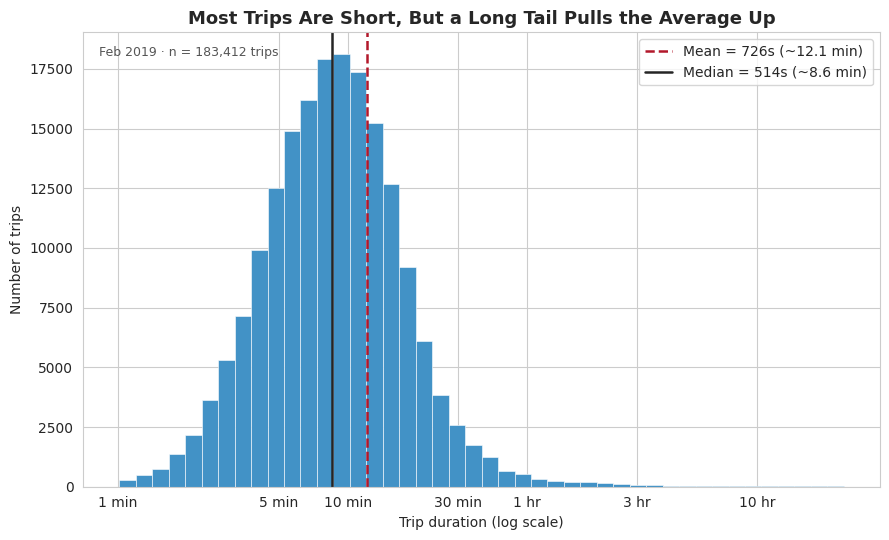

In [8]:
fig, ax = plt.subplots(figsize=(9, 5.5))
log_dur = np.log10(df['duration_sec'])
bins = np.linspace(log_dur.min(), log_dur.max(), 45)
ax.hist(log_dur, bins=bins, color='#4292c6', edgecolor='white', linewidth=0.4)
mean_s, median_s = df['duration_sec'].mean(), df['duration_sec'].median()
ax.axvline(np.log10(mean_s), color='#b2182b', linestyle='--', linewidth=1.8,
           label=f'Mean = {mean_s:.0f}s (~{mean_s/60:.1f} min)')
ax.axvline(np.log10(median_s), color='#252525', linestyle='-', linewidth=1.8,
           label=f'Median = {median_s:.0f}s (~{median_s/60:.1f} min)')
ax.set_xticks(np.log10(DUR_TICKS))
ax.set_xticklabels(DUR_LABELS)
ax.set_xlabel('Trip duration (log scale)')
ax.set_ylabel('Number of trips')
ax.set_title('Most Trips Are Short, But a Long Tail Pulls the Average Up', fontsize=13, fontweight='bold')
ax.legend(frameon=True, loc='upper right')
ax.text(0.02, 0.97, 'Feb 2019 · n = 183,412 trips', transform=ax.transAxes,
        fontsize=9, color='#555555', va='top')
plt.tight_layout()
plt.show()

> A log scale is used here because the raw data is skewed enough that a linear axis would hide the shape entirely — nearly every trip would pile into the first bar. Even on the log axis, the mean (12 min) sits noticeably above the median (8.6 min): a relatively small number of very long trips are pulling the average up. This sets the baseline the rest of the notebook builds on — the question from here is *what explains the spread*, not whether there is one.

## Customers Ride Longer Than Subscribers

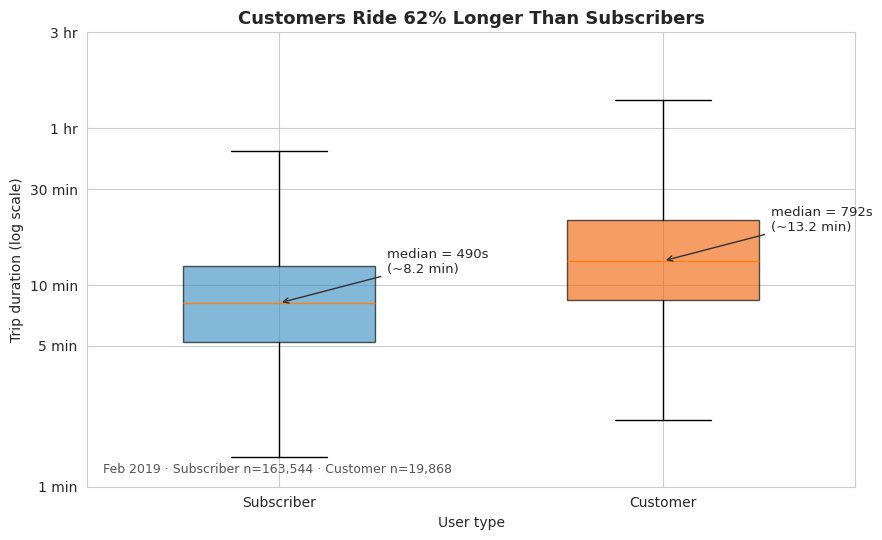

In [5]:
fig, ax = plt.subplots(figsize=(9, 5.5))
order = ['Subscriber', 'Customer']
data = [np.log10(df.loc[df['user_type'] == ut, 'duration_sec']) for ut in order]
bp = ax.boxplot(data, tick_labels=order, showfliers=False, patch_artist=True, widths=0.5)
colors = ['#4292c6', '#f16913']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.65)
for i, ut in enumerate(order):
    med = df.loc[df['user_type'] == ut, 'duration_sec'].median()
    ax.annotate(f'median = {med:.0f}s\n(~{med/60:.1f} min)', xy=(i + 1, np.log10(med)),
                xytext=(i + 1.28, np.log10(med) + 0.15), fontsize=9.5,
                arrowprops=dict(arrowstyle='->', color='#333333'))
ax.set_yticks(np.log10(DUR_TICKS[:6]))
ax.set_yticklabels(DUR_LABELS[:6])
ax.set_ylabel('Trip duration (log scale)')
ax.set_xlabel('User type')
ax.set_title('Customers Ride 62% Longer Than Subscribers', fontsize=13, fontweight='bold')
ax.text(0.02, 0.03, 'Feb 2019 · Subscriber n=163,544 · Customer n=19,868',
        transform=ax.transAxes, fontsize=9, color='#555555')
plt.tight_layout()
plt.show()

> User Type is the strongest split in the dataset. Subscribers (89% of all trips) ride short and consistently — median 8.2 min, tight interquartile range. Customers (the remaining 11%) ride noticeably longer at a median of 13.2 min. This single split — Subscriber vs. Customer — turns out to matter more than any other feature tested in this dataset, including age. The next chart asks whether that gap is constant, or whether it depends on the day.

## The Gap Isn't Constant — It Only Widens for Customers

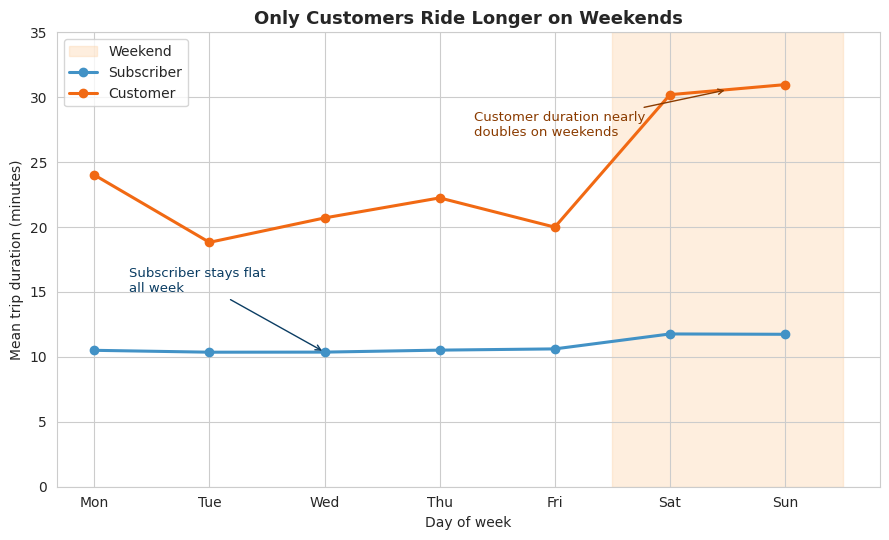

In [6]:
pivot = df.pivot_table(index='day_of_week', columns='user_type', values='duration_sec',
                        aggfunc='mean', observed=False).reindex(DAY_ORDER) / 60

fig, ax = plt.subplots(figsize=(9, 5.5))
x = range(7)
ax.axvspan(4.5, 6.5, color='#fdd0a2', alpha=0.35, zorder=0, label='Weekend')
ax.plot(x, pivot['Subscriber'], marker='o', color='#4292c6', linewidth=2.2, label='Subscriber')
ax.plot(x, pivot['Customer'], marker='o', color='#f16913', linewidth=2.2, label='Customer')
ax.annotate('Customer duration nearly\ndoubles on weekends',
            xy=(5.5, pivot['Customer'].iloc[5:7].mean()),
            xytext=(3.3, 27), fontsize=9.5, color='#8a3b00',
            arrowprops=dict(arrowstyle='->', color='#8a3b00'))
ax.annotate('Subscriber stays flat\nall week', xy=(2, pivot['Subscriber'].iloc[2]),
            xytext=(0.3, 15), fontsize=9.5, color='#0b3d63',
            arrowprops=dict(arrowstyle='->', color='#0b3d63'))
ax.set_xticks(list(x))
ax.set_xticklabels(DAY_SHORT)
ax.set_xlabel('Day of week')
ax.set_ylabel('Mean trip duration (minutes)')
ax.set_ylim(0, 35)
ax.set_title('Only Customers Ride Longer on Weekends', fontsize=13, fontweight='bold')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, loc='upper left', frameon=True)
plt.tight_layout()
plt.show()

> Subscriber duration is essentially flat, Monday through Sunday (~10-12 min) — consistent with a commute that doesn't change much by day. Customer duration climbs sharply on Saturday and Sunday, nearly doubling from ~19-24 min on weekdays to ~30-31 min on weekends. This was checked against the underlying distributions (not shown here, see the exploratory notebook) to confirm it's a genuine shape change and not a handful of long trips dragging a mean — Customer trip-duration *distributions* visibly widen on weekend days, they don't just shift on average.

> Worth noting: this chart shows *duration*, not *volume*. Subscriber trip counts are roughly flat all week too (~2,400-3,400/day) — the weekend effect here is specifically about how long each trip lasts, not how many people ride.

## The Variable That Doesn't Matter: Age


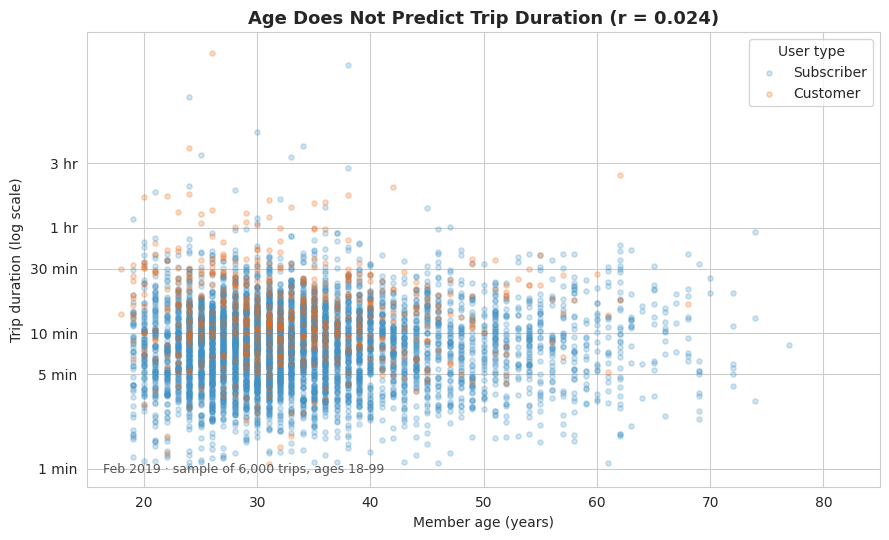

In [7]:
fig, ax = plt.subplots(figsize=(9, 5.5))
sample = df_age_clean.dropna(subset=['age']).sample(n=6000, random_state=42)
for ut, color in zip(['Subscriber', 'Customer'], ['#4292c6', '#f16913']):
    d = sample[sample['user_type'] == ut]
    ax.scatter(d['age'], np.log10(d['duration_sec']), alpha=0.25, s=14, color=color, label=ut)
ax.set_yticks(np.log10(DUR_TICKS[:6]))
ax.set_yticklabels(DUR_LABELS[:6])
ax.set_xlim(15, 85)
ax.set_xlabel('Member age (years)')
ax.set_ylabel('Trip duration (log scale)')
corr = np.corrcoef(df_age_clean['age'], np.log10(df_age_clean['duration_sec']))[0, 1]
ax.set_title(f'Age Does Not Predict Trip Duration (r = {corr:.3f})', fontsize=13, fontweight='bold')
ax.legend(frameon=True, loc='upper right', title='User type')
ax.text(0.02, 0.03, 'Feb 2019 · sample of 6,000 trips, ages 18-99',
        transform=ax.transAxes, fontsize=9, color='#555555')
plt.tight_layout()
plt.show()


> Age is the variable most people would guess matters — younger riders taking quick trips, older riders taking longer leisure rides, or some version of that story. The data doesn't support it: correlation between age and log-duration is 0.0245, indistinguishable from zero, and the cloud of points looks the same shape at 20 as it does at 60, within both Subscriber and Customer groups separately. This is presented as a deliberate finding rather than an omission — ruling out the "obvious" explanation is part of the story, not a gap in it.

## Conclusion

> Returning to the overarching question — **who rides differently, and does the story change once you account for who's riding** — the answer is `user_type`, not age, and not really day-of-week on its own either. Subscribers and Customers behave like two distinct populations: Subscribers are consistent, short-trip commuters all week; Customers ride longer overall and specifically ride much longer on weekends, consistent with leisure/tourist use. Age, despite being the most intuitive candidate, explains none of it. Any further investigation into this dataset (for example, station-level or geographic patterns, which were not explored here) should treat `user_type` as the primary lens, not age or raw day-of-week counts alone.

In [ ]:
!jupyter nbconvert <Part_II_Filename>.ipynb --to slides --post serve --no-input --no-prompt